# 🔧 NASA Turbofan RUL — Analyse Exploratoire des Données

> Dataset C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) — NASA Ames Research Center, 2008

## 📋 Sommaire

1. [Imports & Configuration](#1-imports--configuration)
2. [Chargement des données](#data-loading)
3. [Analyse fondamentale](#fundamental-analysis)
4. [Analyse des variables](#variables-analysis)
5. [Analyse univariée](#5-analyse-univariee)
6. [Analyse multivariée](#6-analyse-multivariee)
7. [Tests statistiques](#7-tests-statistiques)
8. [Conclusions](#8-conclusions)

## 1. Imports & Configuration <a id="1-imports--configuration"></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 2. Chargement des données <a id="data-loading"></a>

In [4]:
col_names = ["unit_number", "time_cycles", "setting_1", "setting_2", "setting_3"]
col_names += [f'sensor_{i}' for i in range(1, 22)]

df_train = pd.read_csv("../data/CMaps/train_FD001.txt", sep=r"\s+", header=None, names=col_names, index_col=False)
df_test = pd.read_csv("../data/CMaps/test_FD001.txt", sep=r"\s+", header=None, names=col_names, index_col=False)

df_train.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Analyse fondamentale <a id="fundamental-analysis"></a>

### Description du dataset

**Quoi :**
Le dataset C-MAPSS simule le comportement de turboréacteurs jusqu'à leur défaillance.
Chaque sous-ensemble (FD001 à FD004) combine des scénarios distincts de conditions opérationnelles et de modes de défaillance.

**Quand & Qui :**
Produit en 2008 par l'équipe de pronostic du NASA Ames Research Center (A. Saxena & K. Goebel).
Utilisé comme référence mondiale lors du PHM 2008 Data Challenge.

**Comment :**
Les données proviennent d'un simulateur haute fidélité — pas de vrais vols.
Un bruit de mesure réaliste est ajouté pour complexifier la prédiction.

**Pourquoi :**
Estimer la RUL (Remaining Useful Life) — combien de cycles reste-t-il avant la panne.
L'enjeu : passer d'une maintenance **préventive** (on change trop tôt par sécurité, coût élevé) à une maintenance **prédictive** (on change juste avant la panne, coût optimisé et sécurité maximale).

### Structure du dataset
Vérifions les dimensions, types et valeurs manquantes.

In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sensor_15    20

**Observations :**
- 20 631 lignes × 26 colonnes
- 4 colonnes entières, 22 flottantes

In [11]:
df_train.isna().sum()

unit_number    0
time_cycles    0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64

**Observations :**
- Aucune valeur manquante
- Le dataset est complet et prêt pour l'analyse

In [9]:
df_train.describe()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


**Observations :**
- Les capteurs ont des échelles très différentes — une **normalisation sera nécessaire** avant la modélisation
- Certains capteurs ont un écart-type très faible et d'autres sont statiques → potentiellement peu informatifs
- `time_cycles` va de 1 à 362 — c'est le compteur de cycles, le maximum correspond au moteur ayant la durée de vie la plus longue

In [12]:
duree_vie = df_train.groupby('unit_number')['time_cycles'].max()
duree_vie.describe().round(2)

count    100.00
mean     206.31
std       46.34
min      128.00
25%      177.00
50%      199.00
75%      229.25
max      362.00
Name: time_cycles, dtype: float64

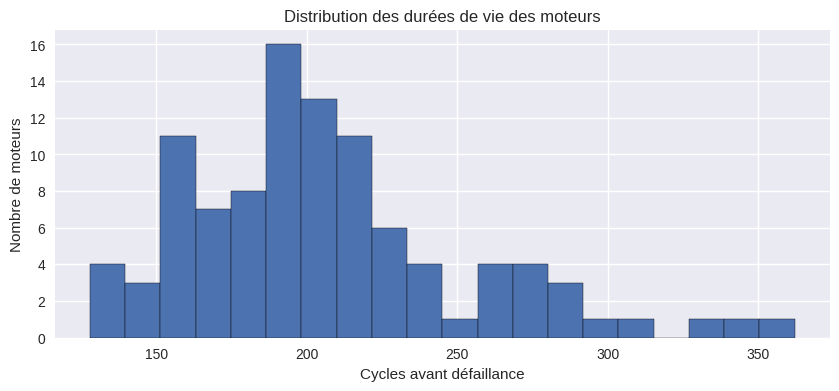

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(duree_vie, bins=20, edgecolor='black')
plt.title("Distribution des durées de vie des moteurs")
plt.xlabel("Cycles avant défaillance")
plt.ylabel("Nombre de moteurs")
plt.show()

**Observations :**
- **100 moteurs** avec des durées de vie variables
- Durée de vie **moyenne** : 206 cycles
- Durée de vie **min** : 128 cycles, **max** : 362 cycles
- **Écart-type** : 46 cycles — variabilité significative entre les moteurs
- La médiane (199) est légèrement inférieure à la moyenne (206) → distribution **asymétrique à droite**
- Quelques moteurs ont une durée de vie exceptionnellement longue (queue vers la droite)